# Bays (2014) Figure 4 — GP-Based Equivalent (Corrected)
## Robustness of Error Distributions Under Tuning and Noise Variations

**Fixes applied:**
1. **Decoder** — removed spurious rate-sum penalty `T_d * Σ gᵢ(θ)` (post-DN rate-sum is constant)

**Kernel note:** This notebook uses a local **periodic kernel** `exp(−2 sin²(d/2) / λ²)`,
which maps exactly onto Bays's von Mises: κ = 1/λ², so **ω = λ²** and λ = √ω.
This is a different kernel from Figures 1–3 which use the core module's **periodic RBF**
`exp(−d²_circ / (2λ²))` where ω = 1/λ² and λ = 1/√ω.
The λ values here (λ=√ω) are correct for this kernel.

### The six panels test robustness against:
| Panel | Manipulation | GP Equivalent |
|-------|-------------|---------------|
| **a** | Broad tuning (ω = 0.5) | λ = √0.5 = 0.707 |
| **b** | Narrow tuning (ω = 0.2) | λ = √0.2 = 0.447 |
| **c** | Baseline activity (f(0) = 0.25) | Constant floor added |
| **d** | Heterogeneous tuning | Per-neuron random λ, amplitude, baseline |
| **e** | Cosine tuning | Half-wave rectified cosine |
| **f** | Correlated activity (c₀ = 0.25) | Latent Gaussian correlated Poisson |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from scipy.stats import vonmises, norm, poisson, gaussian_kde
from scipy.special import i0, i1
import time
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 150

## Core Building Blocks

In [2]:
def periodic_rbf_kernel(thetas, lengthscale):
    """
    Periodic kernel: K(θ,θ') = exp(-2 sin²(|θ-θ'|/2) / λ²)
    
    This is the kernel that maps exactly onto von Mises:
      von Mises: exp(κ(cos(d)-1)) = exp(-2κ sin²(d/2))
      This kernel: exp(-2 sin²(d/2) / λ²)
    So κ = 1/λ² and ω = 1/κ = λ².
    
    NOTE: This differs from the core module's periodic_rbf_kernel
    which uses exp(-d²_circ/(2λ²)) where ω = 1/λ².
    """
    diff = thetas[:, None] - thetas[None, :]
    return np.exp(-2.0 * np.sin(diff / 2.0)**2 / lengthscale**2)


def sample_gp_function(K, rng):
    """Draw f ~ GP(0, K). Exponentiate for positive tuning: g = exp(f)."""
    n = K.shape[0]
    L = np.linalg.cholesky(K + 1e-8 * np.eye(n))
    return L @ rng.randn(n)


def dn_pointwise(g_col, gamma, sigma_sq, mean_g):
    """Divisive normalisation: r_i = γ · g_i / (σ² + mean_g)"""
    return gamma * g_col / (sigma_sq + mean_g)


def generate_spikes(rates, T_d, rng):
    """Independent Poisson spikes."""
    return rng.poisson(np.maximum(rates * T_d, 0.0))


def circular_error(theta_true, theta_hat):
    """Signed circular distance in [-π, π]."""
    return np.angle(np.exp(1j * (theta_hat - theta_true)))

## Von Mises Fitting

In [3]:
def estimate_kappa_ml(errors):
    """ML estimate of von Mises kappa via Mardia & Jupp approximation."""
    R_bar = np.abs(np.mean(np.exp(1j * errors)))
    R_bar = np.clip(R_bar, 1e-10, 1.0 - 1e-10)
    if R_bar < 0.53:
        kappa = 2 * R_bar + R_bar**3 + 5 * R_bar**5 / 6
    elif R_bar < 0.85:
        kappa = -0.4 + 1.39 * R_bar + 0.43 / (1 - R_bar)
    else:
        kappa = 1.0 / (2*(1-R_bar) - (1-R_bar)**2 - (1-R_bar)**3)
    return max(kappa, 0.01)


def compute_deviation(errors, n_eval=200):
    """KDE-smoothed error distribution and deviation from best-fit von Mises."""
    eval_pts = np.linspace(-np.pi, np.pi, n_eval)
    kappa = estimate_kappa_ml(errors)
    vm_pdf = vonmises.pdf(eval_pts, kappa)
    try:
        kde = gaussian_kde(errors, bw_method=0.2)
        emp = kde(eval_pts)
    except Exception:
        emp = vm_pdf.copy()
    return {'centers': eval_pts, 'empirical': emp, 'von_mises': vm_pdf,
            'deviation': emp - vm_pdf, 'kappa': kappa}

## Population Generators

In [4]:
def make_gp_population(M, n_theta, lengthscale, seed):
    """Homogeneous GP population (panels a, b)."""
    rng = np.random.RandomState(seed)
    thetas = np.linspace(-np.pi, np.pi, n_theta, endpoint=False)
    K = periodic_rbf_kernel(thetas, lengthscale)
    g = np.zeros((M, n_theta))
    for i in range(M):
        g[i] = np.exp(sample_gp_function(K, rng))
    return thetas, g


def make_gp_with_baseline(M, n_theta, lengthscale, baseline_frac, seed):
    """GP + constant baseline floor (panel c)."""
    thetas, g = make_gp_population(M, n_theta, lengthscale, seed)
    if baseline_frac > 1e-10:
        mean_peak = np.mean(np.max(g, axis=1))
        f0 = baseline_frac * mean_peak / (1.0 - baseline_frac)
        g = g + f0
    return thetas, g


def make_heterogeneous_population(M, n_theta, config, seed):
    """Heterogeneous: per-neuron random λ, amplitude, baseline (panel d)."""
    rng = np.random.RandomState(seed)
    thetas = np.linspace(-np.pi, np.pi, n_theta, endpoint=False)
    g = np.zeros((M, n_theta))
    lam_mean, lam_std = config.get('lambda_narrow', 0.3), config.get('lambda_std', 0.1)
    for i in range(M):
        lam_i = max(0.05, rng.normal(lam_mean, lam_std))
        amp_i = max(0.01, rng.normal(1.0, 0.5))
        bl_i = max(0.0, rng.normal(0.25, 0.125))
        K = periodic_rbf_kernel(thetas, lam_i)
        g[i] = amp_i * np.exp(sample_gp_function(K, rng)) + bl_i
    return thetas, g


def make_cosine_population(M, n_theta, config, seed):
    """Half-wave rectified cosine tuning (panel e)."""
    rng = np.random.RandomState(seed)
    thetas = np.linspace(-np.pi, np.pi, n_theta, endpoint=False)
    prefs = rng.uniform(-np.pi, np.pi, M)
    g = np.zeros((M, n_theta))
    for i in range(M):
        amp_i = max(0.01, rng.normal(1.0, 0.5))
        bl_i = max(0.0, rng.normal(0.25, 0.125))
        g[i] = amp_i * np.maximum(0.0, np.cos(thetas - prefs[i])) + bl_i
    return thetas, g

## Correlated Spike Generation (Panel f)

Short-range correlations: $c_{ij} = c_0 \exp(-|\phi_i - \phi_j|)$ (Bays Eq. 19)

Generated via latent Gaussian method (Macke et al. 2008).

In [5]:
def build_correlation_matrix(M, c0):
    """Short-range pairwise correlations (Bays Eq. 19)."""
    prefs = np.linspace(-np.pi, np.pi, M, endpoint=False)
    diff = np.abs(prefs[:, None] - prefs[None, :])
    diff = np.minimum(diff, 2*np.pi - diff)
    C = c0 * np.exp(-diff)
    np.fill_diagonal(C, 1.0)
    return C, prefs


def precompute_cholesky(corr_matrix):
    try:
        return np.linalg.cholesky(corr_matrix)
    except np.linalg.LinAlgError:
        eigvals, eigvecs = np.linalg.eigh(corr_matrix)
        eigvals = np.maximum(eigvals, 1e-6)
        C_fixed = eigvecs @ np.diag(eigvals) @ eigvecs.T
        np.fill_diagonal(C_fixed, 1.0)
        return np.linalg.cholesky(C_fixed)


def generate_correlated_spikes(rates, T_d, chol_L, rng):
    """Correlated Poisson via latent Gaussian with precomputed Cholesky."""
    M = len(rates)
    lambdas = np.maximum(rates * T_d, 1e-10)
    z = chol_L @ rng.randn(M)
    u = np.clip(norm.cdf(z), 1e-10, 1.0 - 1e-10)
    counts = poisson.ppf(u, mu=lambdas).astype(int)
    return np.maximum(counts, 0)

## Trial Engine

In [6]:
def run_trials(g, thetas, gamma, T_d, sigma_sq, n_trials, rng, chol_L=None):
    """
    Run n_trials of encode → normalise → spike → decode → error.
    
    FIX: Decoder uses only spike-weighted log-tuning (no rate-sum penalty).
    The rate-sum Σᵢ rᵢ(θ) is constant post-DN (Activity Cap), so it
    drops from argmax. The old code subtracted T_d × Σᵢ gᵢ(θ) (pre-DN
    sum) which varies with θ for GP populations, biasing the decoder.
    """
    M, n_theta = g.shape
    log_g = np.log(np.maximum(g, 1e-30))
    mean_g = np.mean(g, axis=0)  # (n_theta,) for DN denominator
    errors = np.empty(n_trials)
    for t in range(n_trials):
        idx_true = rng.randint(n_theta)
        rates = dn_pointwise(g[:, idx_true], gamma, sigma_sq, mean_g[idx_true])
        if chol_L is not None:
            counts = generate_correlated_spikes(rates, T_d, chol_L, rng)
        else:
            counts = generate_spikes(rates, T_d, rng)
        # FIX: decoder — no rate-sum penalty
        ll = counts @ log_g  # shape (n_theta,)
        idx_hat = np.argmax(ll)
        errors[t] = circular_error(thetas[idx_true], thetas[idx_hat])
    return errors

## Configuration

In [7]:
N_THETA = 128
N_TRIALS = 3000
N_TRIALS_LARGE = 1500  # for M=1000 (panel f)
T_D = 0.1
SIGMA_SQ = 1e-6

# Tuning widths (GP lengthscales)
# This notebook uses the periodic kernel exp(-2 sin²(d/2)/λ²)
# where ω = λ² (NOT ω = 1/λ² as in the core module's periodic RBF).
LAMBDA_BROAD = np.sqrt(0.5)   # ω = 0.5 (broad tuning)
LAMBDA_NARROW = np.sqrt(0.2)  # ω = 0.2 (narrow tuning)
LAMBDA_STD = 0.1
BASELINE_FRAC = 0.25
C0 = 0.25

# Gain values: Bays sweeps gamma from ~1 to ~128 Hz (total subpop output).
GAMMAS_TOTAL = [1, 2, 4, 8, 16, 32, 64, 128]
M_DEFAULT = 100
GAMMAS = [g / M_DEFAULT for g in GAMMAS_TOTAL]

N_EVAL = 200
SEED = 42

config = {
    'n_theta': N_THETA, 'lambda_narrow': LAMBDA_NARROW,
    'lambda_std': LAMBDA_STD, 'baseline_frac': BASELINE_FRAC, 'c0': C0,
}

print(f'Gamma range: {GAMMAS[0]:.3f} to {GAMMAS[-1]:.3f} Hz/neuron')
print(f'Total output range: {GAMMAS_TOTAL[0]} to {GAMMAS_TOTAL[-1]} Hz')
print(f'Kernel: periodic exp(-2 sin²(d/2)/λ²), so ω = λ²')
print(f'Broad:  λ={LAMBDA_BROAD:.3f} → ω={LAMBDA_BROAD**2:.2f}')
print(f'Narrow: λ={LAMBDA_NARROW:.3f} → ω={LAMBDA_NARROW**2:.2f}')

Gamma range: 0.010 to 1.280 Hz/neuron
Total output range: 1 to 128 Hz
Kernel: periodic exp(-2 sin²(d/2)/λ²), so ω = λ²
Broad:  λ=0.707 → ω=0.50
Narrow: λ=0.447 → ω=0.20


## Run All Six Panels

Panels a–e use M=100 only. Panel f uses both M=100 (solid) and M=1000 (dashed).

In [8]:
panel_generators = {
    'a': ('Broad GP\ntuning',    lambda M, s: make_gp_population(M, N_THETA, LAMBDA_BROAD, s)),
    'b': ('Narrow GP\ntuning',   lambda M, s: make_gp_population(M, N_THETA, LAMBDA_NARROW, s)),
    'c': ('Baseline\nactivity',  lambda M, s: make_gp_with_baseline(M, N_THETA, LAMBDA_NARROW, BASELINE_FRAC, s)),
    'd': ('Heterogeneous\ntuning', lambda M, s: make_heterogeneous_population(M, N_THETA, config, s)),
    'e': ('Cosine\ntuning',      lambda M, s: make_cosine_population(M, N_THETA, config, s)),
}

panels = {}
t0 = time.time()

# Panels a-e: M=100 only
for pid, (title, gen_fn) in panel_generators.items():
    pt = time.time()
    thetas, g = gen_fn(100, SEED + ord(pid))
    panels[pid] = {'title': title, 'thetas': thetas, 'g': g, 'pop_sizes': [100], 'results': {}}
    panels[pid]['g_example_100'] = g[:30]

    for gam in GAMMAS:
        rng = np.random.RandomState(SEED + 100 + int(gam * 10000))
        errs = run_trials(g, thetas, gam, T_D, SIGMA_SQ, N_TRIALS, rng)
        panels[pid]['results'][(gam, 100)] = compute_deviation(errs, N_EVAL)
    print(f'  Panel {pid} ({title.split(chr(10))[0]}) done ({time.time()-pt:.1f}s)')

# Panel f: M=100 and M=1000, with correlations
pid = 'f'
pt = time.time()
panels[pid] = {'title': 'Correlated\nactivity', 'pop_sizes': [100, 1000], 'results': {}}

for M in [100, 1000]:
    thetas, g = make_gp_population(M, N_THETA, LAMBDA_NARROW, SEED + M + 500)
    corr_mat, _ = build_correlation_matrix(M, C0)
    chol_L = precompute_cholesky(corr_mat)

    panels[pid]['thetas'] = thetas
    panels[pid][f'g_example_{M}'] = g[:30]
    panels[pid][f'corr_matrix_{M}'] = corr_mat

    gammas_M = [gt / M for gt in GAMMAS_TOTAL]
    nt = N_TRIALS if M <= 100 else N_TRIALS_LARGE
    for gam in gammas_M:
        rng = np.random.RandomState(SEED + M + int(gam * 10000))
        errs = run_trials(g, thetas, gam, T_D, SIGMA_SQ, nt, rng, chol_L)
        panels[pid]['results'][(gam, M)] = compute_deviation(errs, N_EVAL)
    print(f'  Panel f M={M} done')

print(f'\nAll panels done in {time.time()-t0:.1f}s')

  Panel a (Broad GP) done (0.8s)
  Panel b (Narrow GP) done (1.2s)
  Panel c (Baseline) done (0.8s)
  Panel d (Heterogeneous) done (1.2s)
  Panel e (Cosine) done (1.2s)
  Panel f M=100 done
  Panel f M=1000 done

All panels done in 12.4s


## Plot: 3 Rows × 6 Columns

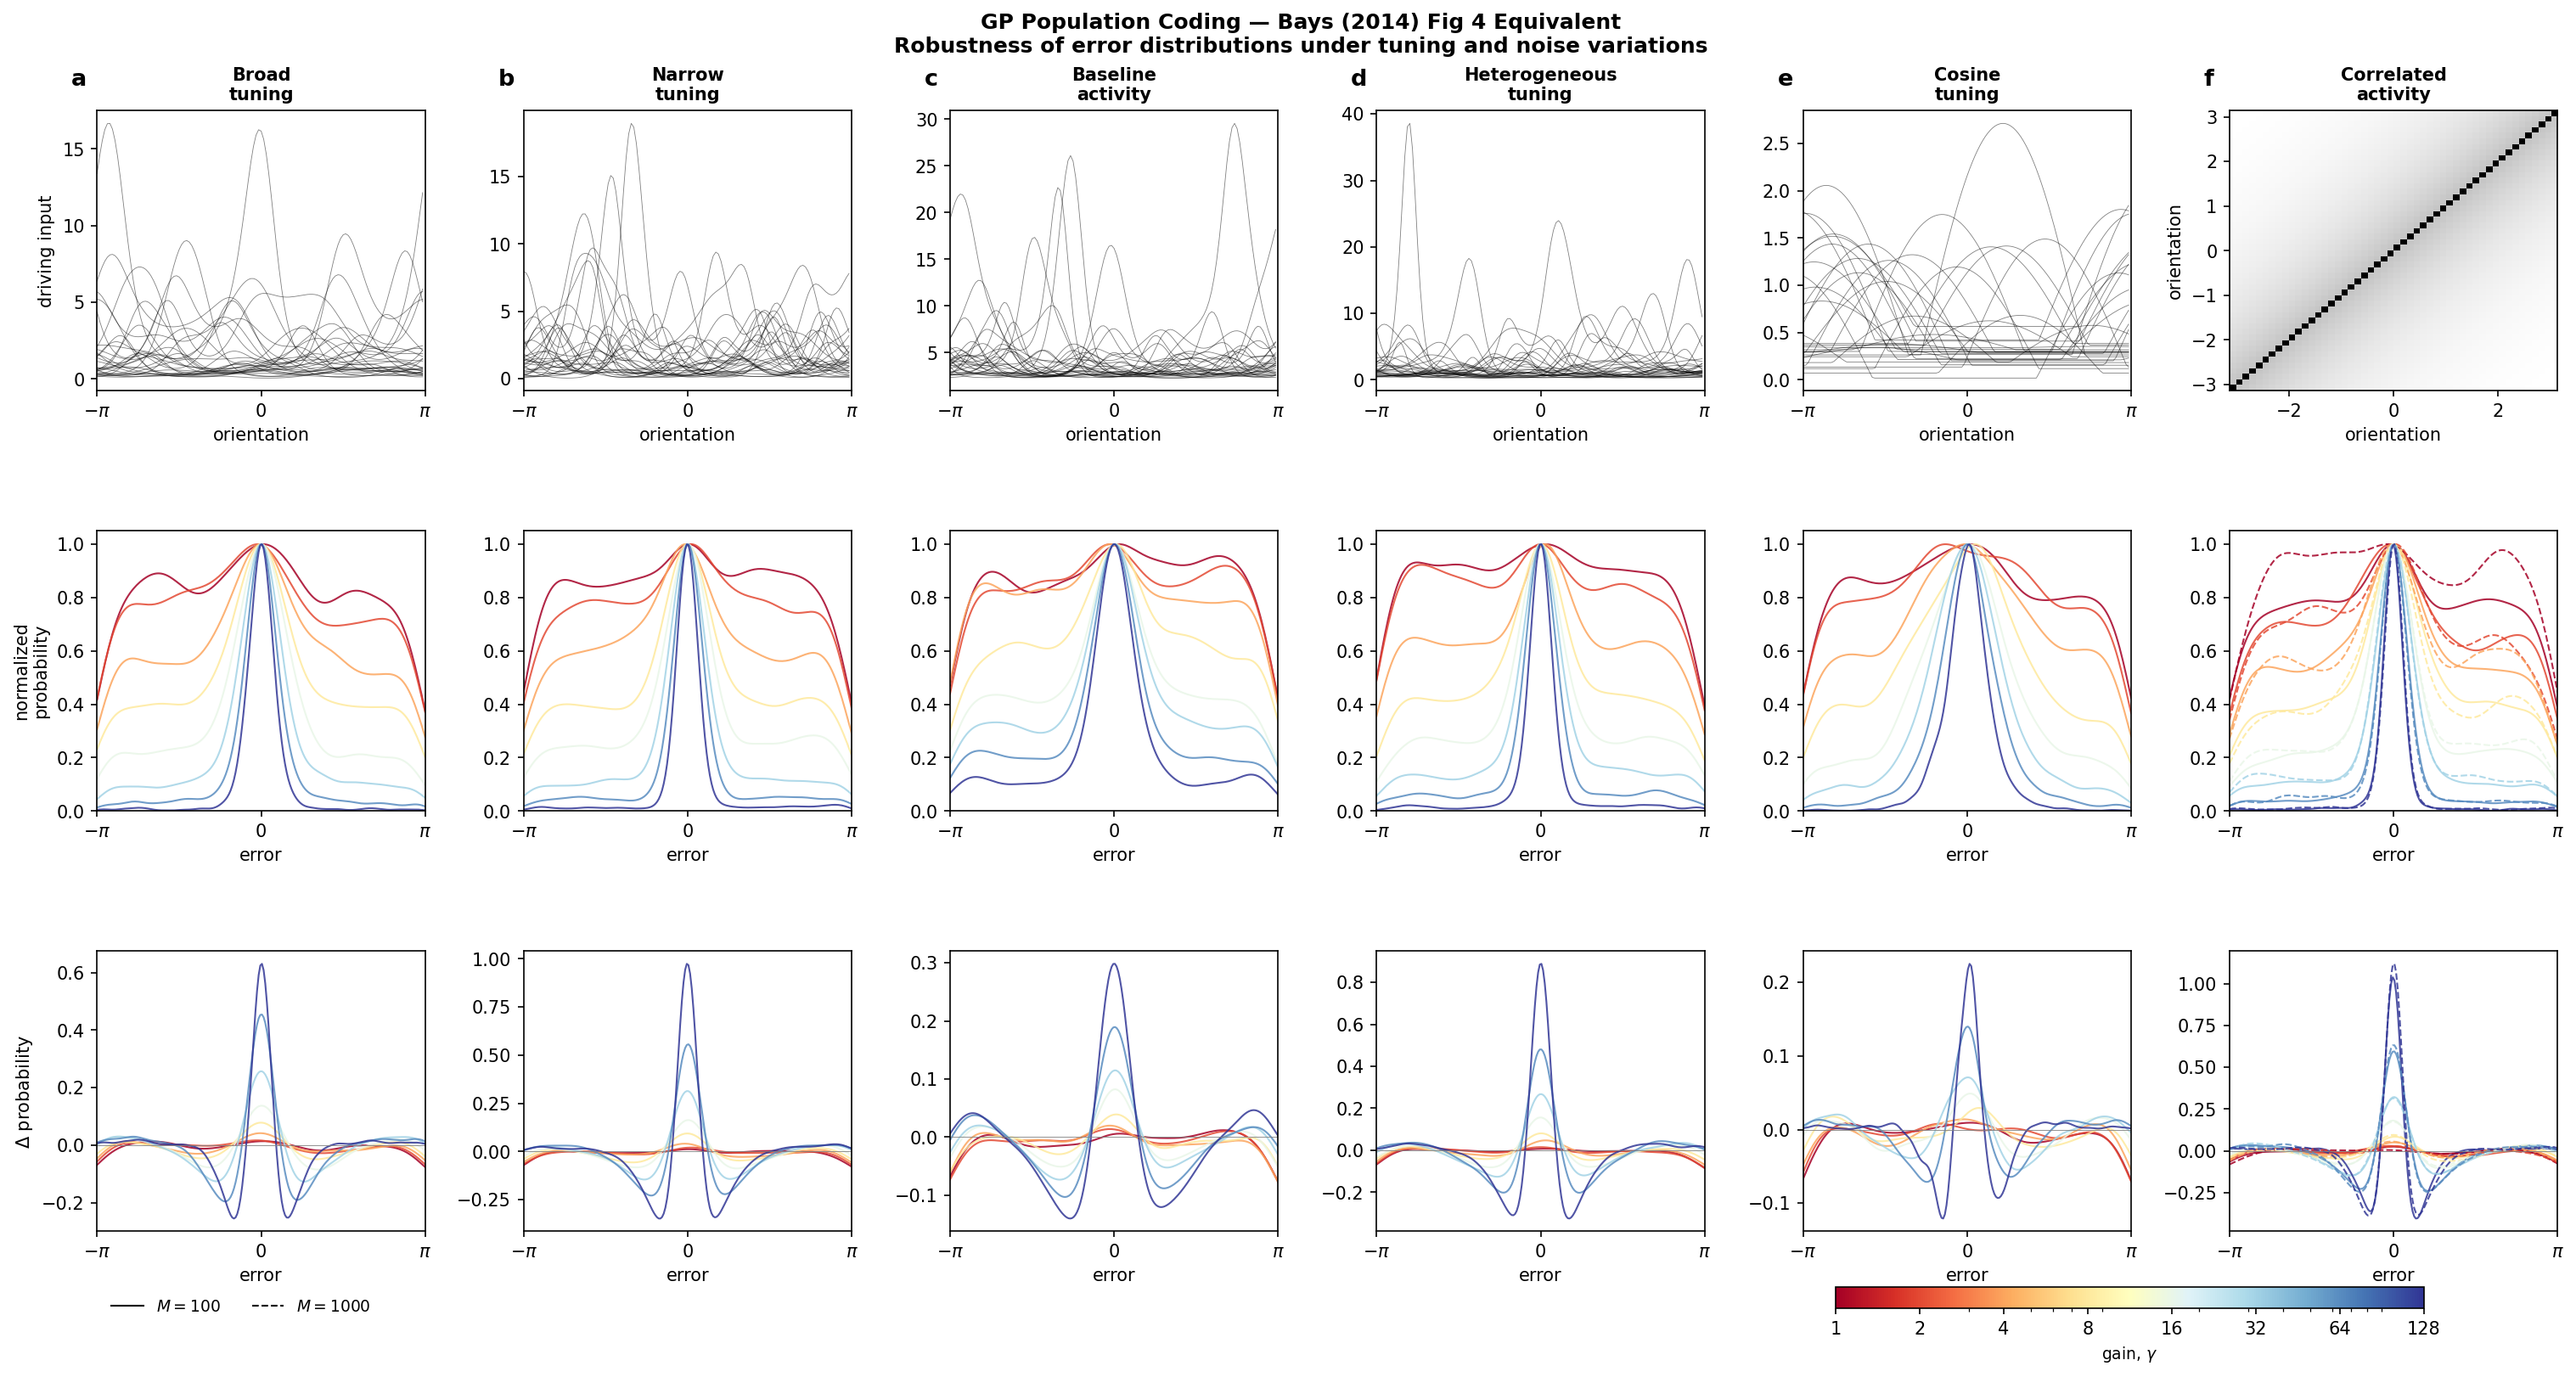

In [9]:
fig = plt.figure(figsize=(21, 11))
gs = gridspec.GridSpec(3, 6, hspace=0.50, wspace=0.30,
                       left=0.05, right=0.97, bottom=0.08, top=0.88)

# Colormap: gain from low (red) to high (blue), matching Bays
gain_cmap = plt.cm.RdYlBu
gain_norm = mcolors.LogNorm(vmin=min(GAMMAS_TOTAL), vmax=max(GAMMAS_TOTAL))

panel_ids = ['a', 'b', 'c', 'd', 'e', 'f']
titles = ['Broad\ntuning', 'Narrow\ntuning', 'Baseline\nactivity',
          'Heterogeneous\ntuning', 'Cosine\ntuning', 'Correlated\nactivity']

for col, pid in enumerate(panel_ids):
    p = panels[pid]
    thetas = p['thetas']
    pop_sizes = p['pop_sizes']
    M_ref = pop_sizes[0]

    # -- ROW 1: Tuning curves / correlation matrix --
    ax_top = fig.add_subplot(gs[0, col])
    if pid == 'f':
        C = p[f'corr_matrix_{M_ref}']
        n_show = min(50, C.shape[0])
        ax_top.imshow(C[:n_show, :n_show], cmap='gray_r', origin='lower',
                      aspect='auto', extent=[-np.pi, np.pi, -np.pi, np.pi])
        ax_top.set_xlabel('orientation'); ax_top.set_ylabel('orientation')
    else:
        g_ex = p.get(f'g_example_{M_ref}', p['g'][:30])
        for i in range(min(30, g_ex.shape[0])):
            ax_top.plot(thetas, g_ex[i], 'k-', lw=0.4, alpha=0.5)
        ax_top.set_xlabel('orientation')
        if col == 0: ax_top.set_ylabel('driving input')
        ax_top.set_xlim(-np.pi, np.pi)
        ax_top.set_xticks([-np.pi, 0, np.pi])
        ax_top.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])

    ax_top.set_title(titles[col], fontsize=10, fontweight='bold')
    ax_top.text(-0.08, 1.15, f'$\\mathbf{{{pid}}}$',
                transform=ax_top.transAxes, fontsize=13, fontweight='bold', va='top')

    # -- ROW 2: Normalised error distributions --
    ax_mid = fig.add_subplot(gs[1, col])
    for M in pop_sizes:
        ls = '-' if M == pop_sizes[0] else '--'
        gammas_M = [gt / M for gt in GAMMAS_TOTAL]
        for gi, gam in enumerate(gammas_M):
            key = (gam, M)
            if key not in p['results']: continue
            dev = p['results'][key]
            emp = dev['empirical']
            peak = emp.max()
            if peak > 0:
                ax_mid.plot(dev['centers'], emp / peak,
                            color=gain_cmap(gain_norm(GAMMAS_TOTAL[gi])),
                            lw=1.0, ls=ls, alpha=0.85)
    ax_mid.set_xlim(-np.pi, np.pi); ax_mid.set_ylim(0, 1.05)
    ax_mid.set_xticks([-np.pi, 0, np.pi])
    ax_mid.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax_mid.set_xlabel('error')
    if col == 0: ax_mid.set_ylabel('normalized\nprobability')

    # -- ROW 3: Deviation from circular normal --
    ax_bot = fig.add_subplot(gs[2, col])
    for M in pop_sizes:
        ls = '-' if M == pop_sizes[0] else '--'
        gammas_M = [gt / M for gt in GAMMAS_TOTAL]
        for gi, gam in enumerate(gammas_M):
            key = (gam, M)
            if key not in p['results']: continue
            dev = p['results'][key]
            ax_bot.plot(dev['centers'], dev['deviation'],
                        color=gain_cmap(gain_norm(GAMMAS_TOTAL[gi])),
                        lw=1.0, ls=ls, alpha=0.85)
    ax_bot.axhline(0, color='gray', lw=0.4)
    ax_bot.set_xlim(-np.pi, np.pi)
    ax_bot.set_xticks([-np.pi, 0, np.pi])
    ax_bot.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax_bot.set_xlabel('error')
    if col == 0: ax_bot.set_ylabel(r'$\Delta$ probability')

# Legend & colorbar
from matplotlib.lines import Line2D
handles = [Line2D([0],[0], color='k', lw=1, ls='-', label='$M=100$'),
           Line2D([0],[0], color='k', lw=1, ls='--', label='$M=1000$')]
fig.legend(handles=handles, loc='lower left', bbox_to_anchor=(0.05, 0.01),
           fontsize=9, frameon=False, ncol=2)

sm = plt.cm.ScalarMappable(cmap=gain_cmap, norm=gain_norm); sm.set_array([])
cbar_ax = fig.add_axes([0.70, 0.025, 0.22, 0.015])
cb = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cb.set_label(r'gain, $\gamma$', fontsize=9)
cb.set_ticks(GAMMAS_TOTAL)
cb.set_ticklabels([str(g) for g in GAMMAS_TOTAL])

fig.suptitle('GP Population Coding \u2014 Bays (2014) Fig 4 Equivalent\n'
             'Robustness of error distributions under tuning and noise variations',
             fontsize=12, fontweight='bold', y=0.95)
plt.savefig('bays_fig4_corrected.png', dpi=150, bbox_inches='tight')
plt.show()